<a href="https://colab.research.google.com/github/Chiamara-22/Fresh-vs-Rotten-mango-classifier-FE8/blob/main/notebook/Fresh_vs_rotten_mango_FE8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle

In [2]:
import kagglehub

path = kagglehub.dataset_download("zlatan599/fruitquality1")

print(path)

100%|██████████| 4.77G/4.77G [00:51<00:00, 99.8MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/zlatan599/fruitquality1/versions/1


In [3]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print("Directories:", dirs)
    print("Files:", files[:5])  # Show first 5 files
    print("-" * 50)

/root/.cache/kagglehub/datasets/zlatan599/fruitquality1/versions/1
Directories: ['Unified_Dataset']
Files: []
--------------------------------------------------
/root/.cache/kagglehub/datasets/zlatan599/fruitquality1/versions/1/Unified_Dataset
Directories: ['strawberry', 'potato', 'carrot', 'cucumber', 'apple', 'pomegranate', 'guava', 'tomato', 'orange', 'jujube', 'banana', 'bellpepper', 'mango', 'grape']
Files: []
--------------------------------------------------
/root/.cache/kagglehub/datasets/zlatan599/fruitquality1/versions/1/Unified_Dataset/strawberry
Directories: ['fresh', 'rotten']
Files: []
--------------------------------------------------
/root/.cache/kagglehub/datasets/zlatan599/fruitquality1/versions/1/Unified_Dataset/strawberry/fresh
Directories: []
Files: ['923.jpg', '624.jpg', '847.jpg', '329.jpg', 'freshStrawberry (260).jpg']
--------------------------------------------------
/root/.cache/kagglehub/datasets/zlatan599/fruitquality1/versions/1/Unified_Dataset/strawberry/

In [4]:
import os
import hashlib
from collections import defaultdict

mango_root = os.path.join(path, "Unified_Dataset", "mango")
fresh_dir = os.path.join(mango_root, "fresh")
rotten_dir = os.path.join(mango_root, "rotten")

def file_hash(filepath):
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

def scan_class(folder, label):
    records = {}
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        if not os.path.isfile(fpath):
            continue
        records[fname] = {
            'label': label,
            'path': fpath,
            'hash': file_hash(fpath),
        }
    return records

fresh_records = scan_class(fresh_dir, 'fresh')
rotten_records = scan_class(rotten_dir, 'rotten')

print(f"Fresh count: {len(fresh_records)}")
print(f"Rotten count: {len(rotten_records)}")

# 1. Filename collisions between classes
name_collisions = set(fresh_records) & set(rotten_records)
print(f"\nFilename collisions (same name, both classes): {len(name_collisions)}")

# 2. Are the colliding filenames actually the SAME image (by content hash)?
true_duplicates = []
different_content = []
for name in name_collisions:
    if fresh_records[name]['hash'] == rotten_records[name]['hash']:
        true_duplicates.append(name)
    else:
        different_content.append(name)

print(f"  -> Same filename AND same content (TRUE duplicate, contradictory label): {len(true_duplicates)}")
print(f"  -> Same filename, DIFFERENT content (just coincidental naming, not a bug): {len(different_content)}")
if true_duplicates:
    print(f"  Examples: {true_duplicates[:10]}")

# 3. Any exact-duplicate images ANYWHERE in mango (cross-class, by content, regardless of filename)?
all_records = list(fresh_records.values()) + list(rotten_records.values())
hash_to_labels = defaultdict(set)
for r in all_records:
    hash_to_labels[r['hash']].add(r['label'])

cross_class_dupes = {h: labels for h, labels in hash_to_labels.items() if len(labels) > 1}
print(f"\nImages whose exact content appears under BOTH labels (content-level contradiction): {len(cross_class_dupes)}")

Fresh count: 1813
Rotten count: 2247

Filename collisions (same name, both classes): 1000
  -> Same filename AND same content (TRUE duplicate, contradictory label): 0
  -> Same filename, DIFFERENT content (just coincidental naming, not a bug): 1000

Images whose exact content appears under BOTH labels (content-level contradiction): 0


## Checking for duplicated images



In [5]:
import os
import re
from collections import Counter

def scan_names(folder):
    return os.listdir(folder)

fresh_names = scan_names(fresh_dir)
rotten_names = scan_names(rotten_dir)

# 1. Within-class exact duplicates (by content hash)
def find_internal_dupes(records):
    hash_counts = Counter(r['hash'] for r in records.values())
    dupes = {h: c for h, c in hash_counts.items() if c > 1}
    return dupes

fresh_dupes = find_internal_dupes(fresh_records)
rotten_dupes = find_internal_dupes(rotten_records)
print(f"Fresh: {len(fresh_dupes)} image(s) duplicated internally, "
      f"{sum(fresh_dupes.values()) - len(fresh_dupes)} redundant copies")
print(f"Rotten: {len(rotten_dupes)} image(s) duplicated internally, "
      f"{sum(rotten_dupes.values()) - len(rotten_dupes)} redundant copies")

# 2. Filename pattern fingerprinting — crude but fast signal of mixed sources
def pattern_bucket(fname):
    if re.match(r'^(rotated_by_\d+_|translation_|vertical_flip_|saltandpepper_)', fname):
        return 'augmented_screenshot_source'
    if re.match(r'^fresh[Mm]ango', fname):
        return 'freshMango_named_source'
    if re.match(r'^rotten[Mm]ango', fname):
        return 'rottenMango_named_source'
    if re.match(r'^\d+\.(jpg|jpeg|png)$', fname, re.IGNORECASE):
        return 'generic_numeric_source'
    if re.search(r'alternaria|anthracnose|blight|scab', fname, re.IGNORECASE):
        return 'disease_dataset_source'
    return 'other'

print("\nFresh filename source patterns:")
print(Counter(pattern_bucket(f) for f in fresh_names))
print("\nRotten filename source patterns:")
print(Counter(pattern_bucket(f) for f in rotten_names))

Fresh: 384 image(s) duplicated internally, 384 redundant copies
Rotten: 483 image(s) duplicated internally, 483 redundant copies

Fresh filename source patterns:
Counter({'generic_numeric_source': 1000, 'freshMango_named_source': 605, 'other': 208})

Rotten filename source patterns:
Counter({'generic_numeric_source': 1000, 'rottenMango_named_source': 593, 'other': 352, 'disease_dataset_source': 302})


## Clean dataset to remove duplicated image in both Fresh and Rotten Mango images

In [6]:
import os
import shutil
import re
from collections import defaultdict
import random

random.seed(42)

EXCLUDE_DISEASE_SOURCE = True  # decision (A) above — flip to False if you're going with (B)

def pattern_bucket(fname):
    if re.match(r'^(rotated_by_\d+_|translation_|vertical_flip_|saltandpepper_)', fname):
        return 'augmented_screenshot_source'
    if re.match(r'^fresh[Mm]ango', fname):
        return 'freshMango_named_source'
    if re.match(r'^rotten[Mm]ango', fname):
        return 'rottenMango_named_source'
    if re.match(r'^\d+\.(jpg|jpeg|png)$', fname, re.IGNORECASE):
        return 'generic_numeric_source'
    if re.search(r'alternaria|anthracnose|blight|scab', fname, re.IGNORECASE):
        return 'disease_dataset_source'
    return 'other'

def dedupe_class(records):
    """Keep exactly one file per unique content hash."""
    seen_hashes = {}
    for fname, meta in records.items():
        h = meta['hash']
        if h not in seen_hashes:
            seen_hashes[h] = (fname, meta)
    return seen_hashes  # hash -> (fname, meta)

fresh_unique = dedupe_class(fresh_records)
rotten_unique = dedupe_class(rotten_records)

print(f"Fresh: {len(fresh_records)} -> {len(fresh_unique)} after dedup")
print(f"Rotten: {len(rotten_records)} -> {len(rotten_unique)} after dedup")

def filter_source(unique_dict):
    kept = []
    excluded = 0
    for h, (fname, meta) in unique_dict.items():
        bucket = pattern_bucket(fname)
        if EXCLUDE_DISEASE_SOURCE and bucket == 'disease_dataset_source':
            excluded += 1
            continue
        kept.append((fname, meta, bucket))
    return kept, excluded

fresh_kept, fresh_excluded = filter_source(fresh_unique)
rotten_kept, rotten_excluded = filter_source(rotten_unique)
print(f"Fresh: {fresh_excluded} disease-source excluded, {len(fresh_kept)} remain")
print(f"Rotten: {rotten_excluded} disease-source excluded, {len(rotten_kept)} remain")

# Stratified split by (label, source_bucket) so each source pattern is
# proportionally represented in train/val/test — not just by label.
def stratified_split(records, train_frac=0.7, val_frac=0.15):
    by_bucket = defaultdict(list)
    for fname, meta, bucket in records:
        by_bucket[bucket].append((fname, meta))

    train, val, test = [], [], []
    for bucket, items in by_bucket.items():
        random.shuffle(items)
        n = len(items)
        n_train = int(n * train_frac)
        n_val = int(n * val_frac)
        train += items[:n_train]
        val += items[n_train:n_train + n_val]
        test += items[n_train + n_val:]
    return train, val, test

fresh_train, fresh_val, fresh_test = stratified_split(fresh_kept)
rotten_train, rotten_val, rotten_test = stratified_split(rotten_kept)

print(f"\nFresh  -> train {len(fresh_train)}, val {len(fresh_val)}, test {len(fresh_test)}")
print(f"Rotten -> train {len(rotten_train)}, val {len(rotten_val)}, test {len(rotten_test)}")

# Materialize into a clean directory structure
out_root = "mango_clean_split"
for split_name, fresh_items, rotten_items in [
    ("train", fresh_train, rotten_train),
    ("validation", fresh_val, rotten_val),
    ("test", fresh_test, rotten_test),
]:
    for cls, items in [("fresh", fresh_items), ("rotten", rotten_items)]:
        dest_dir = os.path.join(out_root, split_name, cls)
        os.makedirs(dest_dir, exist_ok=True)
        for fname, meta in items:
            shutil.copy2(meta['path'], os.path.join(dest_dir, fname))

print(f"\nClean split written to: {out_root}/")

Fresh: 1813 -> 1429 after dedup
Rotten: 2247 -> 1764 after dedup
Fresh: 0 disease-source excluded, 1429 remain
Rotten: 301 disease-source excluded, 1463 remain

Fresh  -> train 999, val 213, test 217
Rotten -> train 1022, val 218, test 223

Clean split written to: mango_clean_split/


## STEP: Point at the CLEAN split, not the raw kagglehub path

In [8]:

mango_root = "mango_clean_split"
mango_train_dir = os.path.join(mango_root, "train")
mango_val_dir   = os.path.join(mango_root, "validation")
mango_test_dir  = os.path.join(mango_root, "test")

## STEP: Imports + reproducibility

In [9]:


import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version: {tf.__version__}')

results_dir = "results/apple_lab/"
os.makedirs(results_dir, exist_ok=True)
os.makedirs('models', exist_ok=True)

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)}' if gpus else 'No GPU — training on CPU (slower).')

TensorFlow version: 2.20.0
GPUs available: 1


## Initilizing  Hyperparameters

In [13]:
IMAGE_HEIGHT = 160
IMAGE_WIDTH  = 160
BATCH_SIZE   = 32
EPOCHS       = 50
LR           = 1e-3
AUTOTUNE = tf.data.AUTOTUNE

INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)

## Loading dataset

In [14]:

mango_train_dataset = tf.keras.utils.image_dataset_from_directory(
    mango_train_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=True,
    label_mode='binary',
)
mango_val_dataset = tf.keras.utils.image_dataset_from_directory(
    mango_val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
    label_mode='binary',
)
mango_test_dataset = tf.keras.utils.image_dataset_from_directory(
    mango_test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
    label_mode='binary',
)

mango_class_names = mango_train_dataset.class_names
print(f'Mango classes: {mango_class_names}')

Found 2021 files belonging to 2 classes.
Found 431 files belonging to 2 classes.
Found 440 files belonging to 2 classes.
Mango classes: ['fresh', 'rotten']


## Pipeline performance

In [15]:

mango_train_dataset = mango_train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
mango_val_dataset   = mango_val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
mango_test_dataset  = mango_test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

## Sanity-check a batch visually before training

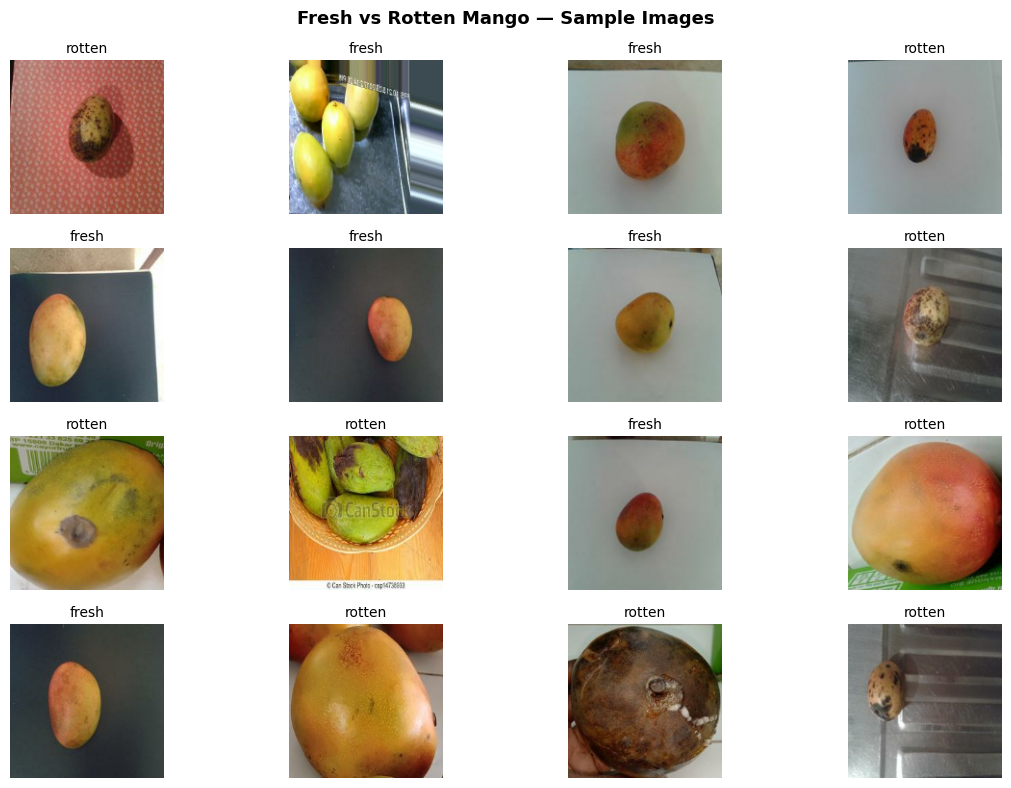

In [16]:

for images, labels in mango_train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    label_idx = int(fixed_labels[i][0])
    plt.title(mango_class_names[label_idx], fontsize=10)
    plt.axis('off')
plt.suptitle('Fresh vs Rotten Mango — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir + 'mango_samples.png', dpi=120, bbox_inches='tight')
plt.show()

#Augmentation
## augment dataset to contain rotated_by_X / translation / flip / saltandpepper copies

In [17]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

In [18]:
def make_callbacks(name):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'models/{name}_best.keras',
            monitor='val_accuracy', save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=4, min_lr=1e-7, verbose=1,
        ),
    ]

def plot_learning_curves(history, title='Learning Curves'):
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
    loss, val_loss = history.history['loss'], history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend(); plt.title(f'{title} — Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend(); plt.title(f'{title} — Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)

    plt.tight_layout()
    safe_title = title.lower().replace(" ", "_")
    plt.savefig(results_dir + f'{safe_title}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

def evaluate_model(model, dataset, class_names, title='Model'):
    """Binary evaluation — single sigmoid output, threshold at 0.5."""
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy().ravel().astype(int))
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    print(f"\n{title}")
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'Recall   : {recall_score(y_true, y_pred):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred):.4f}')
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt='d',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'fontsize': 11, 'fontweight': 'bold'})
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    safe_title = title.lower().replace(" ", "_")
    plt.savefig(results_dir + f'{safe_title}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()
    return accuracy_score(y_true, y_pred)

## Building the Custom CNN model

In [19]:
def build_custom_cnn(input_shape, augmentation):
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)

    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)   # single unit — binary

    return tf.keras.Model(inputs, outputs, name='custom_cnn')

cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)
cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             

 Total params: 322,081 (1.23 MB)

 Trainable params: 321,185 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [21]:
# STEP: Compile + train
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

cnn_history = cnn_model.fit(
    mango_train_dataset, validation_data=mango_val_dataset, epochs=EPOCHS,
    callbacks=make_callbacks('custom_cnn'), verbose=1,
)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 175ms/step - accuracy: 0.7328 - loss: 0.5260 - val_accuracy: 0.4942 - val_loss: 1.1252 - learning_rate: 0.0010
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.8916 - loss: 0.2721 - val_accuracy: 0.4942 - val_loss: 1.8710 - learning_rate: 0.0010
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - accuracy: 0.9362 - loss: 0.1801 - val_accuracy: 0.4942 - val_loss: 1.8602 - learning_rate: 0.0010
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - accuracy: 0.9401 - loss: 0.1699 - val_accuracy: 0.4896 - val_loss: 1.6894 - learning_rate: 0.0010
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9643 - loss: 0.1061
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.9560 - loss: 0.1219 - val_accuracy: 0.4872 - val_loss: 2.3593 - learning_rate: 0.0010
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.9733 - loss: 0.07

## Evaluting the Dataset

Custom CNN -> val_loss: 0.0815, val_accuracy: 0.9861


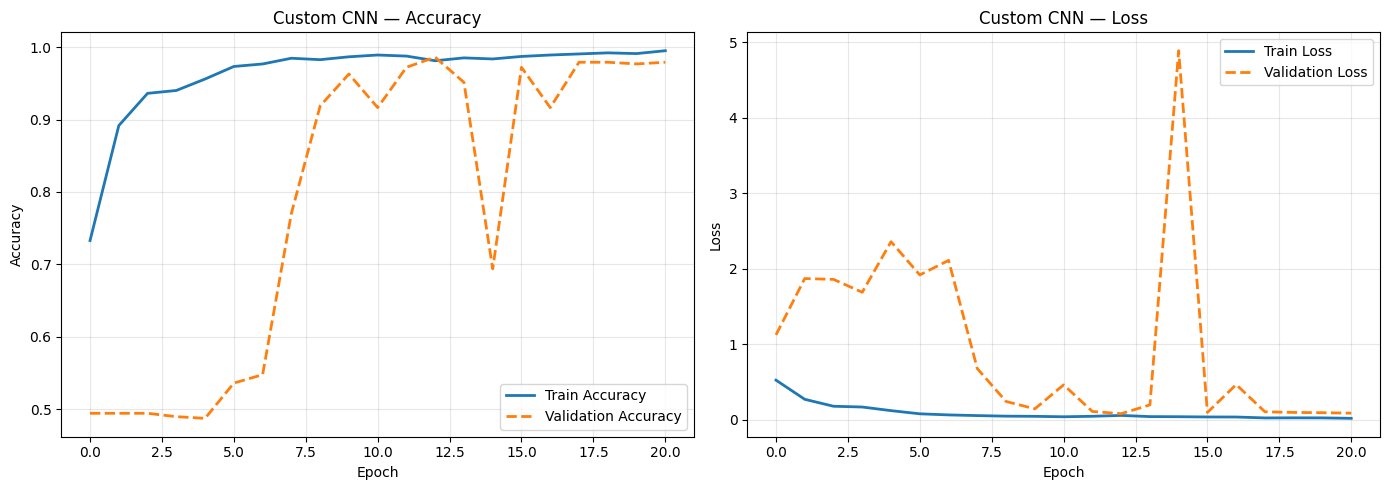


Custom CNN
Accuracy : 0.9864
Precision: 0.9910
Recall   : 0.9821
F1-Score : 0.9865

Classification Report:
              precision    recall  f1-score   support

       fresh     0.9817    0.9908    0.9862       217
      rotten     0.9910    0.9821    0.9865       223

    accuracy                         0.9864       440
   macro avg     0.9863    0.9864    0.9864       440
weighted avg     0.9864    0.9864    0.9864       440



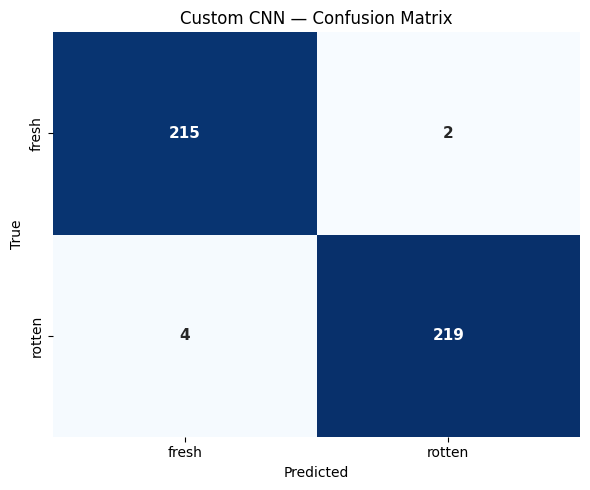

In [22]:

cnn_val_loss, cnn_val_acc = cnn_model.evaluate(mango_val_dataset, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}, val_accuracy: {cnn_val_acc:.4f}')

plot_learning_curves(cnn_history, 'Custom CNN')
cnn_test_acc = evaluate_model(cnn_model, mango_test_dataset, mango_class_names, 'Custom CNN')